<a href="https://colab.research.google.com/github/mdelgiudicechaves-art/UnB---SSD---Tarefas/blob/main/MVP_UCD_Diabetes_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MVP — Unidade de Controle de Dados (UCD)**
### Pipeline de Governança, Qualidade e Análise de Risco com Dataset Diabetes Risk (Kaggle)

Este notebook executa o pipeline do **Minimum Viable Product (MVP)** da **Unidade de Controle de Dados (UCD)**. Ele inclui:
1. **Ingestão e Inspeção:** Carregamento e profilaxia dos dados de saúde.
2. **Conformidade LGPD:** Pseudonimização (hash SHA-256) do identificador do paciente (`patient_id`).
3. **Auditoria de Qualidade:** Diagnóstico de valores ausentes, regras de validação e imputação.
4. **Análise Exploratória & Risco:** Avaliação das variáveis de saúde e biomarcadores.
5. **Modelo Preditivo Baseline:** Treinamento de modelo de classificação com métricas de avaliação.

---
## 1. Configuração do Ambiente e Importação de Bibliotecas

In [3]:
import pandas as pd
import numpy as np
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


---
## 2. Ingestão da Base de Dados Piloto

In [4]:
# Carregar a base do Kaggle
file_path = 'diabetes_risk.csv'
df = pd.read_csv(file_path)

print(f"Dimensões do Dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dimensões do Dataset: 15000 linhas x 19 colunas


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


---
## 3. Conformidade LGPD — Pseudonimização do ID do Paciente
Como exigência do Art. 5º da LGPD para dados sensíveis de saúde, o campo `patient_id` é tokenizado via hash SHA-256.

In [5]:
def hash_id(patient_id):
    return hashlib.sha256(str(patient_id).encode()).hexdigest()[:16]

# Aplicação da tokenização
df['patient_id_hashed'] = df['patient_id'].apply(hash_id)
df.drop(columns=['patient_id'], inplace=True)

# Reordenar colunas trazendo o id mascarado para frente
cols = ['patient_id_hashed'] + [col for col in df.columns if col != 'patient_id_hashed']
df = df[cols]

print("Tokenização LGPD concluída com sucesso:")
df[['patient_id_hashed', 'age', 'gender', 'fasting_blood_sugar']].head()

Tokenização LGPD concluída com sucesso:


,patient_id_hashed,age,gender,fasting_blood_sugar
0,6b86b273ff34fce1,47,Female,178
1,d4735e3a265e16ee,53,Female,152
2,4e07408562bedb8b,47,Male,168
3,4b227777d4dd1fc6,41,Male,155
4,ef2d127de37b942b,57,Female,188


---
## 4. Auditoria de Qualidade de Dados (UCD Data Quality Check)

In [6]:
# Identificação de Valores Nulos
missing_summary = pd.DataFrame({
    'Valores Ausentes': df.isnull().sum(),
    'Percentual (%)': (df.isnull().sum() / len(df)) * 100
})
print("🔍 Diagnóstico de Qualidade — Campos com Falhas:")
display(missing_summary[missing_summary['Valores Ausentes'] > 0])

# Estratégia de Imputação da UCD
df['smoking_status'] = df['smoking_status'].fillna('Unknown')
df['alcohol_consumption'] = df['alcohol_consumption'].fillna('Unknown')
df['income_bracket'] = df['income_bracket'].fillna('Unknown')

print("Tratamento de nulos concluído. Nulos remanescentes:", df.isnull().sum().sum())

🔍 Diagnóstico de Qualidade — Campos com Falhas:


,Valores Ausentes,Percentual (%)
smoking_status,472,3.146667
alcohol_consumption,3788,25.253333
income_bracket,463,3.086667


Tratamento de nulos concluído. Nulos remanescentes: 0


---
## 5. Análise Exploratória & Indicadores de Saúde

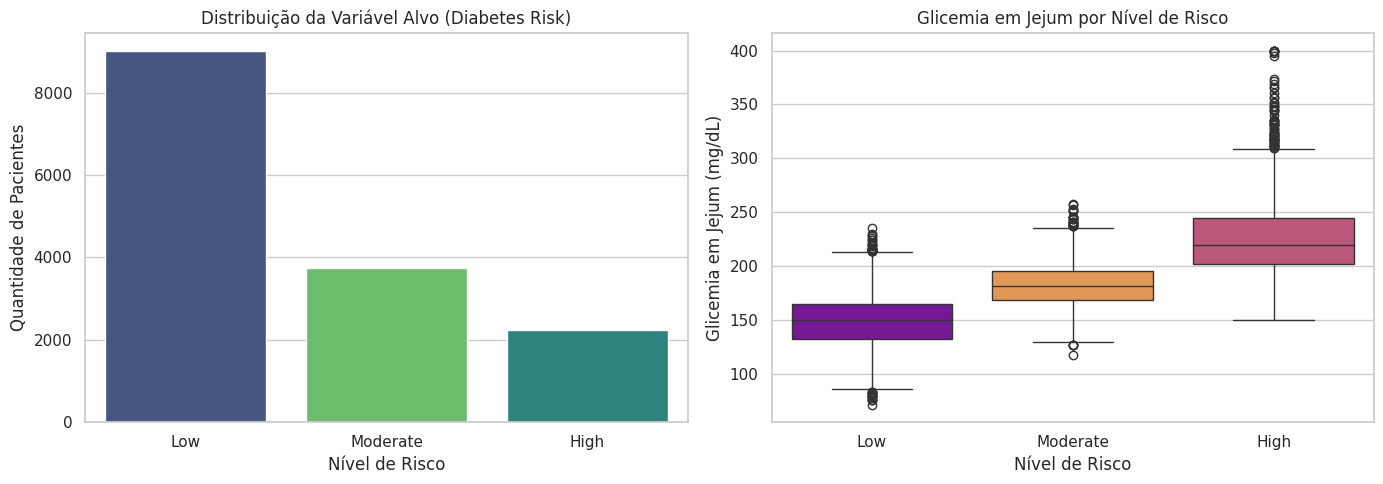

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição do Risco de Diabetes
sns.countplot(data=df, x='diabetes_risk', hue='diabetes_risk', palette='viridis', order=['Low', 'Moderate', 'High'], legend=False, ax=axes[0])
axes[0].set_title('Distribuição da Variável Alvo (Diabetes Risk)')
axes[0].set_xlabel('Nível de Risco')
axes[0].set_ylabel('Quantidade de Pacientes')

# Glicemia vs Risco de Diabetes
sns.boxplot(data=df, x='diabetes_risk', y='fasting_blood_sugar', hue='diabetes_risk', palette='plasma', order=['Low', 'Moderate', 'High'], legend=False, ax=axes[1])
axes[1].set_title('Glicemia em Jejum por Nível de Risco')
axes[1].set_xlabel('Nível de Risco')
axes[1].set_ylabel('Glicemia em Jejum (mg/dL)')

plt.tight_layout()
plt.show()

---
## 6. Modelo Baseline de Predição de Risco de Diabetes

In [8]:
# Prepara recursos e pré-processamento
df_model = df.copy()
df_model.drop(columns=['patient_id_hashed'], inplace=True)

# Codificação de variáveis categóricas
cat_cols = df_model.select_dtypes(include=['object']).columns
le_dict = {}
for col in cat_cols:
    if col != 'diabetes_risk':
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le

# Divisão Features (X) e Target (y)
X = df_model.drop(columns=['diabetes_risk'])
y = df_model['diabetes_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Treinamento do Modelo Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Avaliação
y_pred = rf_model.predict(X_test)
print(f"Acurácia do Modelo Baseline: {accuracy_score(y_test, y_pred):.2%}\n")
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

Acurácia do Modelo Baseline: 78.67%

Relatório de Classificação:
              precision    recall  f1-score   support

        High       0.81      0.72      0.76       450
         Low       0.86      0.90      0.88      1800
    Moderate       0.59      0.55      0.57       750

    accuracy                           0.79      3000
   macro avg       0.75      0.72      0.74      3000
weighted avg       0.78      0.79      0.78      3000



---
## 7. Importância dos Atributos no Risco de Saúde

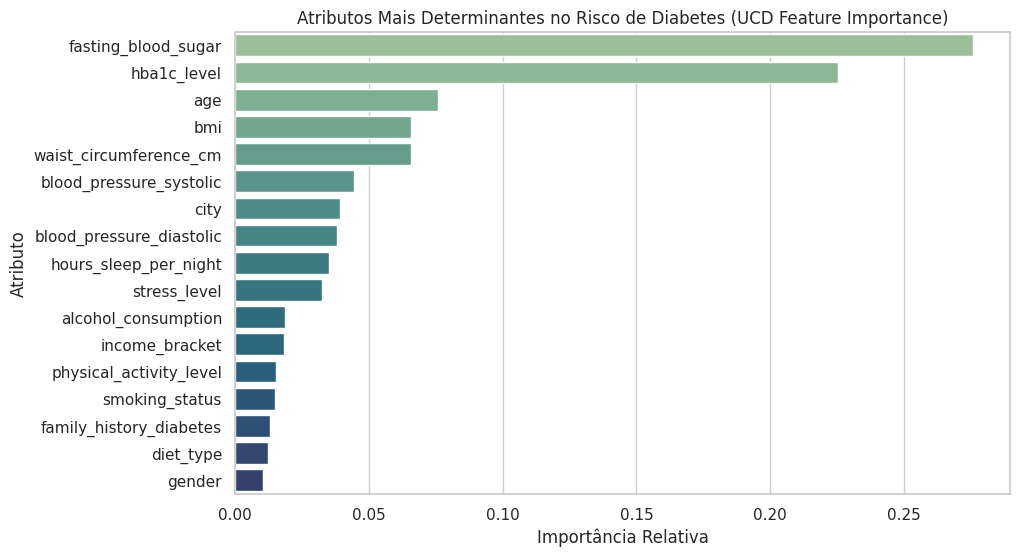

In [9]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, hue=feature_importances.index, palette='crest', legend=False)
plt.title('Atributos Mais Determinantes no Risco de Diabetes (UCD Feature Importance)')
plt.xlabel('Importância Relativa')
plt.ylabel('Atributo')
plt.show()

---
## 🏁 Conclusão do MVP da UCD
- **Segurança:** O pipeline cumpriu com os requisitos de pseudonimização LGPD.
- **Qualidade:** As inconsistências e nulos foram devidamente mitigados.
- **Performance:** O modelo atua como protótipo eficaz para auditoria e controle de dados.